In [325]:
import pickle as pkl
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.corpus import brown
from nltk import download
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import random
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [326]:
import importlib
import enc_dec_lstm
importlib.reload(enc_dec_lstm)
from enc_dec_lstm import Encoder, Decoder, Encoder_Decoder_Model

In [327]:
device = "xpu" if torch.xpu.is_available() else "cpu"
device

'xpu'

In [328]:
with open('../data/train_data.pkl', 'rb') as f:
    train_data = pkl.load(f)

with open('../data/test_data.pkl', 'rb') as f:
    test_data = pkl.load(f)

In [329]:
word_counts = Counter(w for sent in train_data for w, _ in sent)
tag_counts = Counter(t for sent in train_data for _, t in sent)

word2idx = {w: i+2 for i, (w, _) in enumerate(word_counts.items()) if word_counts[w] > 1}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1
idx2word = {i: w for w, i in word2idx.items()}

tag2idx = {t: i+2 for i, (t, _) in enumerate(tag_counts.items())}
tag2idx["<PAD>"] = 0
tag2idx["<SOS>"] = 1
idx2tag = {i: t for t, i in tag2idx.items()}

In [330]:
vocab_size = len(word2idx)
tag_size = len(tag2idx)

In [331]:
MAX_LEN = 50

In [332]:
class POSTagDataset(Dataset):
    def __init__(self, sentences):
        self.data = []
        for sent in sentences:
            words, tags = zip(*sent)
            # if len(words) > MAX_LEN:
            #     words = words[:MAX_LEN]
            #     tags = tags[:MAX_LEN]
            # else:
            #     words = list(words) + ["<PAD>"] * (MAX_LEN - len(words))
            #     tags = list(tags) + ["<PAD>"] * (MAX_LEN - len(tags))
            
            word_ids = [word2idx.get(w, 1) for w in words]
            tag_ids = [tag2idx.get(t, 0) if t in tag2idx else 0 for t in tags]

            length = len(word_ids)

            self.data.append((torch.tensor(word_ids).to(device), torch.tensor(tag_ids).to(device), length))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [333]:
test_dataset = POSTagDataset(test_data)

In [334]:
batch_size=128
test_loader = DataLoader(test_dataset, batch_size=1)

In [343]:
epochs = 25
embed_dim = 64
hidden_dim = 128
model=Encoder_Decoder_Model(vocab_size, embed_dim, hidden_dim, tag_size, tag2idx["<SOS>"]).to(device)
lr=0.001
model.load_state_dict(torch.load(f'models/encoder_decoder_model_{lr}lr_{batch_size}bs_{epochs}epochs.pth', map_location=device))

<All keys matched successfully>

In [344]:
preds=[]
actuals=[]

In [345]:
count=-1

In [346]:
with torch.no_grad():
    for test_batch in tqdm(test_loader, desc="Testing", total=len(test_loader)):
        words_batch, tags_batch, length_batch = test_batch
        input_seq = words_batch
        output_tags = model.generate(input_seq, words_batch.shape[1], length_batch)
        tags=[[idx2tag[idx.item()] for idx in output_tags[i]] for i in range(len(output_tags))]
        preds+=tags[0][1:]
        actuals+=[idx2tag[idx.item()] for idx in tags_batch[0]]
        if count==0:
            break
        count-=1

Testing: 100%|██████████| 5734/5734 [05:17<00:00, 18.05it/s]


In [347]:
len(preds), len(actuals)

(115827, 115827)

In [348]:
words_batch[0]

tensor([  227,  3877,  5508,   498,   505,   204,     4,  1853,  1855,    22,
        41657,     4,     1,  6146,    25,   537,   431,  2391,    15,     9,
         1480,  1519,    11], device='xpu:0')

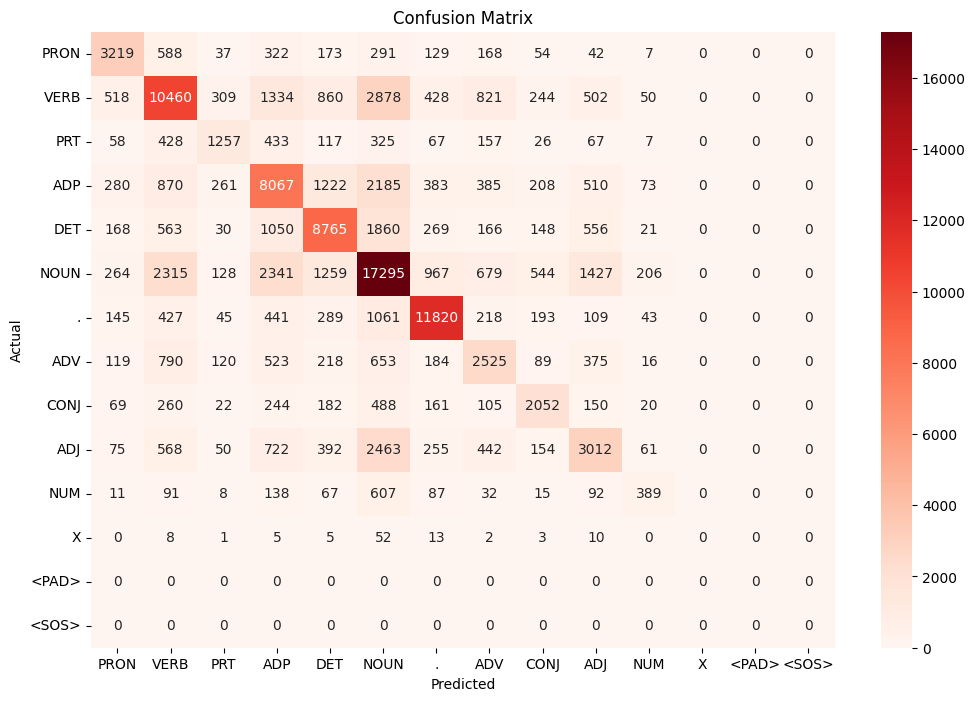

In [349]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(tag2idx.keys()))
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(tag2idx.keys()),
    yticklabels=list(tag2idx.keys()),
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

In [350]:
print(classification_report(
    actuals, preds, labels=list(tag2idx.keys()), digits=4
))

c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

              precision    recall  f1-score   support

        PRON     0.6535    0.6400    0.6466      5030
        VERB     0.6023    0.5684    0.5848     18404
         PRT     0.5542    0.4273    0.4825      2942
         ADP     0.5165    0.5585    0.5367     14444
         DET     0.6469    0.6447    0.6458     13596
        NOUN     0.5735    0.6306    0.6007     27425
           .     0.8007    0.7991    0.7999     14791
         ADV     0.4430    0.4499    0.4464      5612
        CONJ     0.5501    0.5468    0.5484      3753
         ADJ     0.4396    0.3676    0.4004      8194
         NUM     0.4356    0.2531    0.3202      1537
           X     0.0000    0.0000    0.0000        99
       <PAD>     0.0000    0.0000    0.0000         0
       <SOS>     0.0000    0.0000    0.0000         0

    accuracy                         0.5945    115827
   macro avg     0.4440    0.4204    0.4295    115827
weighted avg     0.5927    0.5945    0.5923    115827



c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deevy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver